In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/nikko/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [ ]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()


In [ ]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)


In [4]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [6]:
import torch
torch.cuda.empty_cache()

if os.path.exists('trained_models/stacking_clf_boost_tuned.pkl'):
    stacking_clf = joblib.load('trained_models/stacking_clf_boost_tuned.pkl')
    print("Stacking Classifier caricato da disco")
else:
    stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(stacking_clf, 'trained_models/stacking_clf_boost_tuned.pkl')
    print("Stacking Classifier trained and saved")

Stacking Classifier caricato da disco


In [ ]:
stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)

In [ ]:
models = sc.train_traditional(X_train, y_train, X_val, y_val)

In [ ]:
voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)


In [7]:
if os.path.exists('trained_models/voting_clf_boost_tuned.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf_boost_tuned.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_boost_tuned.pkl')
    print("Voting Classifier trained and saved")

# for m in (train_m, val_m):
#         print(
#             f"  [{m['dataset']}] Acc={m['accuracy']:.2f}%  "
#             f"P={m['precision']:.2f}  R={m['recall']:.2f}  F1={m['f1']:.2f}"
#         )

Voting Classifier caricato da disco


In [ ]:
import torch
from stellar_classification.models.network import SimpleNN

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

if os.path.exists('trained_models/nn_model_index_NOz.pth'):
    nn_model = SimpleNN(input_size, num_classes)
    nn_model.load_state_dict(torch.load('trained_models/nn_model_index_NOz.pth'))
    nn_model.eval()
    print("NN caricata da disco")
else:
    nn_model = sc.train_neural( 
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=input_size,
        num_classes=num_classes,
        num_epochs=10,
        lr=0.001
    )
    torch.save(nn_model.state_dict(), 'trained_models/nn_model_index_NOz.pth')
    print("NN trained nad saved")

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)
    
nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)


NameError: name 'torch' is not defined

In [ ]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/voting_matrix_index_NOz')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/staking_matrix_index_NOz')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network', save_path='/home/nikko/Immagini/res/conf_matrix/NN_matrix_index_NOz')


1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.00545, 0.00365, 0.0019 , 0.0079 , 0.00285, 0.00365, 0.0061 ,
       0.0252 , 0.01275, 0.0897 , 0.0822 , 0.13555, 0.04925]), array([0.0039 , 0.00815, 0.00615, 0.01005, 0.0051 , 0.00525, 0.00835,
       0.03325, 0.01655, 0.0911 , 0.07045, 0.14175, 0.0607 ]), array([0.0025 , 0.00465, 0.00055, 0.0086 , 0.00165, 0.0056 , 0.00755,
       0.03185, 0.0139 , 0.08805, 0.07115, 0.1336 , 0.0466 ]), array([0.00765, 0.00965, 0.0072 , 0.0129 , 0.0025 , 0.0072 , 0.00975,
       0.0321 , 0.0195 , 0.0939 , 0.07645, 0.1457 , 0.0515 ]), array([ 1.77226407e-03,  4.51927337e-03,  6.20292424e-04,  7.53212229e-03,
        8.86132034e-05, -4.44089210e-17,  1.06335844e-03,  2.61408950e-02,
        1.21400089e-02,  9.48161276e-02,  6.94727514e-02,  1.28489145e-01,
        4.83828090e-02])]
Saved: /home/nikko/Immagini/res/permutation_importances/voting_perm_index_NOz.png


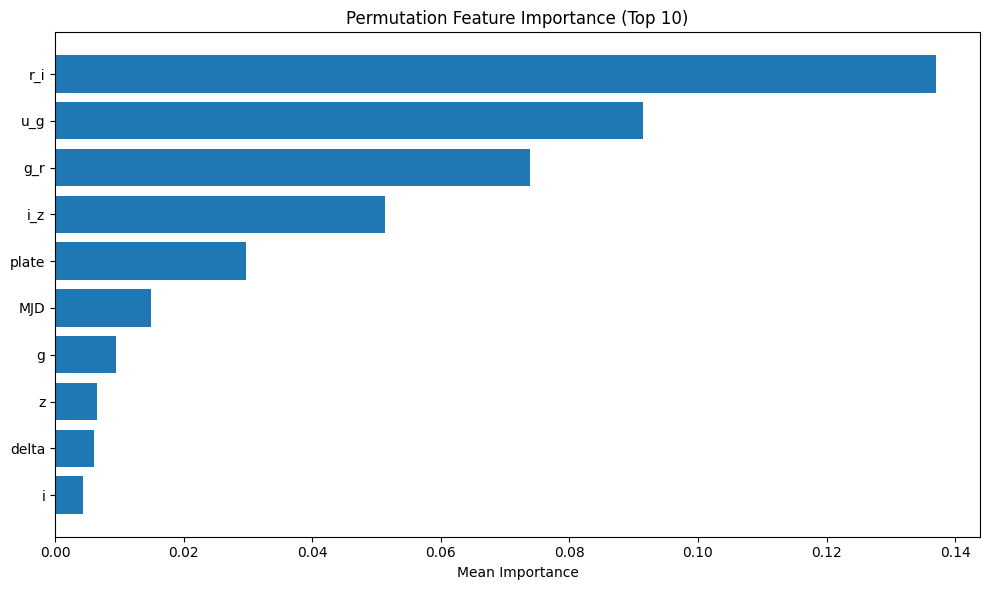

Feature Importance Scores:
r_i: 0.1370
u_g: 0.0915
g_r: 0.0739
i_z: 0.0513
plate: 0.0297
MJD: 0.0150
g: 0.0094
z: 0.0066
delta: 0.0061
i: 0.0043
alpha: 0.0043
u: 0.0033
r: 0.0024
1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.00755, 0.0062 , 0.05235, 0.03555, 0.0105 , 0.01655, 0.02915,
       0.0289 , 0.02505, 0.1081 , 0.07995, 0.1999 , 0.06425]), array([0.0028 , 0.0044 , 0.04585, 0.03185, 0.01085, 0.01525, 0.02935,
       0.0331 , 0.02375, 0.1063 , 0.0739 , 0.19935, 0.07365]), array([0.0044 , 0.00685, 0.0475 , 0.0342 , 0.01265, 0.02145, 0.03645,
       0.0288 , 0.0233 , 0.1091 , 0.0776 , 0.1913 , 0.06565]), array([0.0013 , 0.00405, 0.05055, 0.03515, 0.011  , 0.0222 , 0.03065,
       0.0327 , 0.0208 , 0.1111 , 0.0736 , 0.20105, 0.06855]), array([-0.00212672,  0.00345591,  0.04838281,  0.03881258,  0.01825432,
        0.01355782,  0.02543199,  0.03092601,  0.02596367,  0.11741249,
        0.07425786,  0.19299956,  0.07195392

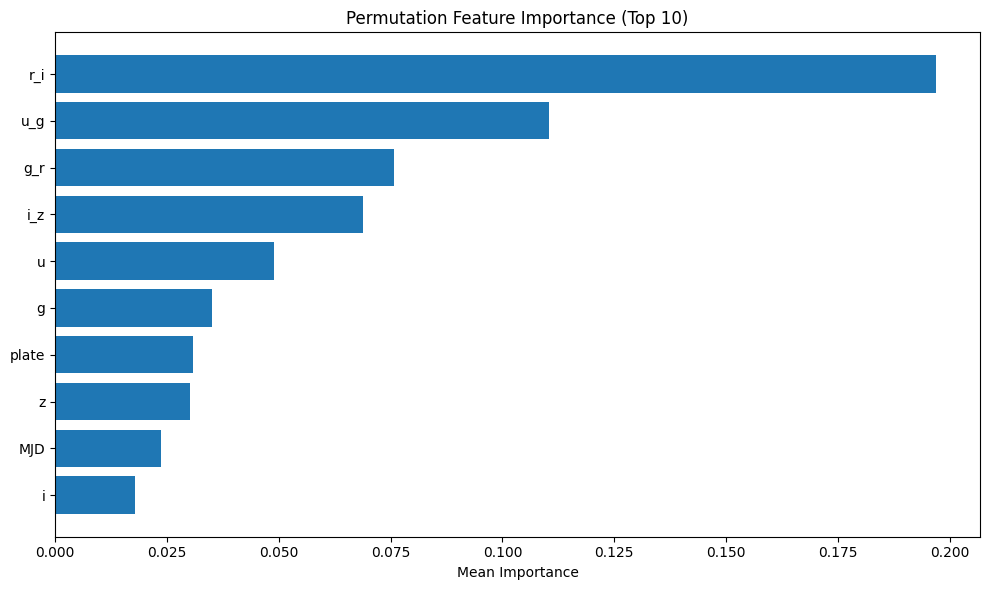

Feature Importance Scores:
r_i: 0.1969
u_g: 0.1104
g_r: 0.0759
i_z: 0.0688
u: 0.0489
g: 0.0351
plate: 0.0309
z: 0.0302
MJD: 0.0238
i: 0.0178
r: 0.0127
delta: 0.0050
alpha: 0.0028


In [11]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/voting_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/stacking_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 



### ottimizzazione feature ablation) ###

Quando passi solo 1-3 feature, le altre vengono azzerate a 0. Ma il modello è stato trainato con i dati normalizzati — uno 0 non significa "feature assente", significa un valore specifico nella scala normalizzata (spesso lontano dalla media). Quindi le feature azzerate introducono rumore invece di essere neutrali.

invece di azzerare, sostituisce con la media della feature.

Saved: /home/nikko/Immagini/res/ablation/Voting_ablation.png


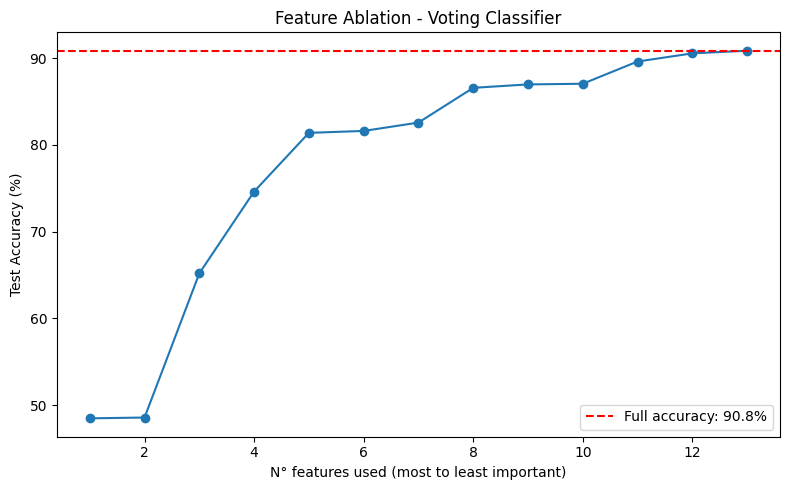

In [8]:
sc.plot_feature_ablation(
    voting_clf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_names,
    title='Feature Ablation - Voting Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Voting_ablation.png'
)

Saved: /home/nikko/Immagini/res/ablation/Stacking_ablation.png


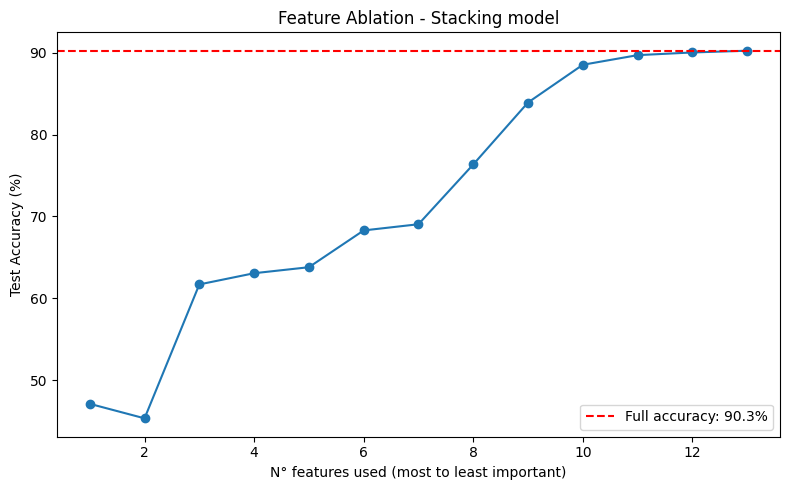

In [9]:
sc.plot_feature_ablation(
    stacking_clf,
    X_train,
    X_test,
    y_train,
    y_test,
    feature_names,
    title='Feature Ablation - Stacking model',
    save_path='/home/nikko/Immagini/res/ablation/Stacking_ablation.png'
)


In [17]:
from sklearn.inspection import permutation_importance


perm = permutation_importance(voting_clf, X_test, y_test, n_repeats=5, n_jobs=1)
imp_series = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
print(imp_series)

print(pd.DataFrame(X_test, columns=feature_names).describe())


r_i      0.139957
u_g      0.091516
g_r      0.075555
i_z      0.050841
plate    0.031330
MJD      0.015194
g        0.009618
z        0.006934
delta    0.005653
alpha    0.005214
i        0.003944
u        0.003757
r        0.002541
dtype: float64
              alpha         delta             u             g             r  \
count  18257.000000  18257.000000  18257.000000  18257.000000  18257.000000   
mean       0.011927      0.002303     -0.010590     -0.008539     -0.003916   
std        0.998176      1.000276      0.994873      0.999935      1.004839   
min       -1.863333     -2.120464     -3.044462     -3.094401     -3.039648   
25%       -0.511201     -0.966468     -0.788725     -0.881969     -0.908729   
50%        0.047704     -0.024824      0.036739      0.216556      0.271586   
75%        0.589196      0.803127      0.701936      0.773424      0.782206   
max        1.912308      2.969606      2.515421      2.477464      2.659939   

                  i             z      

## "Meta-learner Coefficient Analysis" ##
Analysis of the LogisticRegression meta-learner coefficients — how much weight the stacking ensemble assigns to each base learner's predictions for each class.

Meta-learner coefficients: weight of the vote


,svc_GALAXY,svc_QSO,svc_STAR,dt_GALAXY,dt_QSO,dt_STAR,rf_GALAXY,rf_QSO,rf_STAR,catboost_GALAXY,catboost_QSO,catboost_STAR,lgbm_GALAXY,lgbm_QSO,lgbm_STAR
GALAXY,-0.316617,0.195807,0.199494,0.117966,-0.014008,-0.025274,4.042697,-2.386412,-1.577601,0.582694,-0.309904,-0.194106,-1.247491,1.128251,0.197924
QSO,0.214506,-0.449715,0.202035,0.026354,0.126487,-0.186016,-2.305764,5.881280,-3.608690,-0.304484,0.251069,0.020242,1.055614,-2.526084,1.437297
STAR,0.102110,0.253909,-0.401529,-0.144321,-0.112479,0.211290,-1.736933,-3.494868,5.186290,-0.278210,0.058836,0.173865,0.191878,1.397834,-1.635221


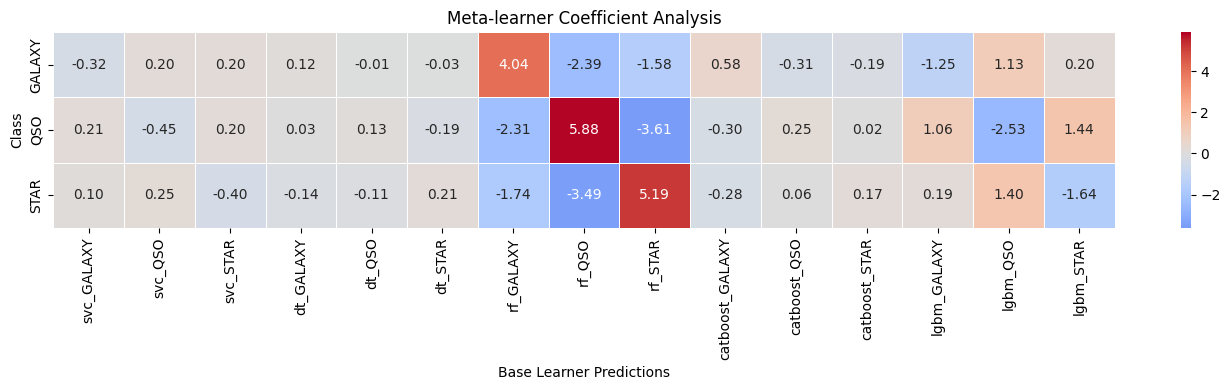

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

meta = stacking_clf.final_estimator_

col_names = [
    f"{name}_{cls}" 
    for name, _ in stacking_clf.estimators
    for cls in label_encoder.classes_
]

coef_df = pd.DataFrame(
    meta.coef_,
    columns=col_names,
    index=label_encoder.classes_
)

print("Meta-learner coefficients: weight of the vote")
display(coef_df)



fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    coef_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Meta-learner Coefficient Analysis')
ax.set_xlabel('Base Learner Predictions')
ax.set_ylabel('Class')

plt.tight_layout()
plt.show()

Un coefficiente alto positivo significa che il meta-learner si fida molto di quel modello per quella classe. Negativo significa che lo usa "al contrario" — se quel modello predice quella classe, il meta-learner tende a non credergli.

## Prediction and error map ##

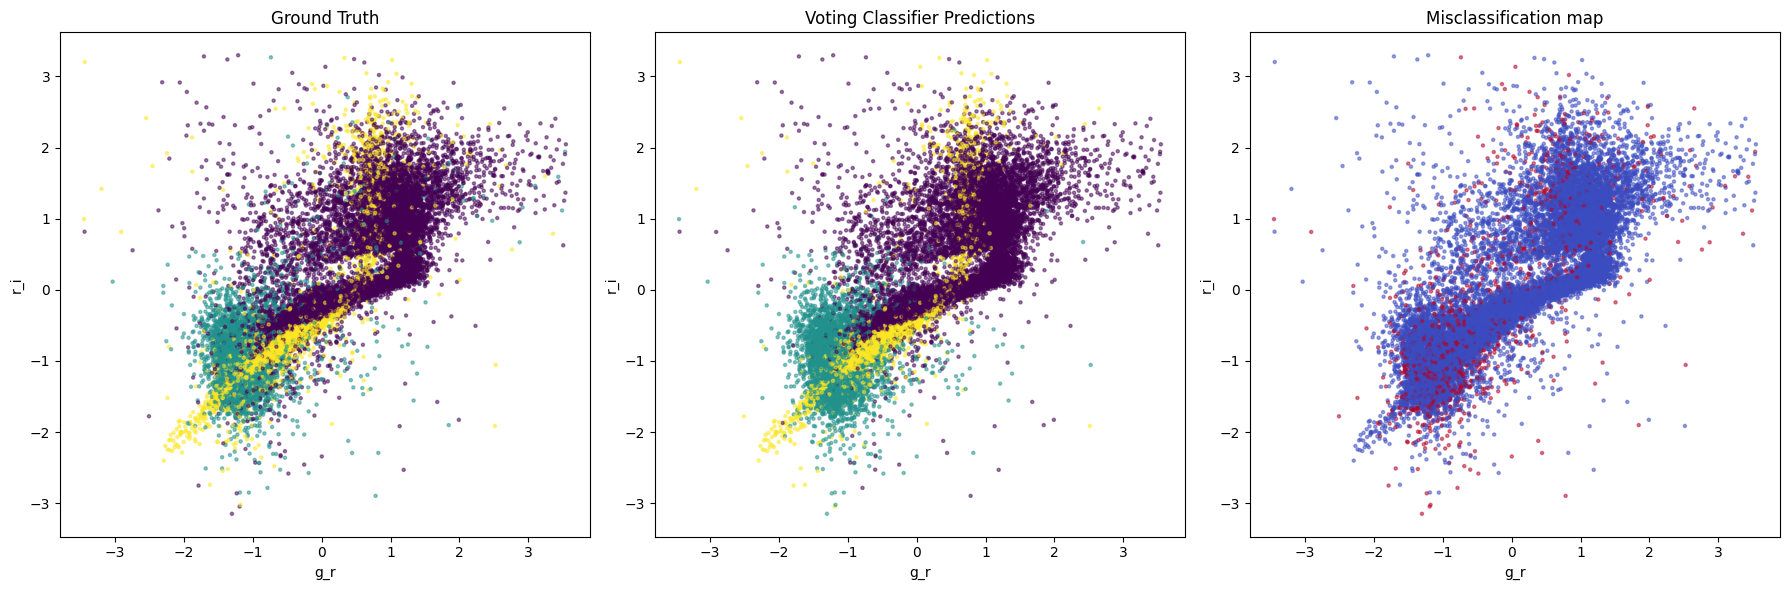

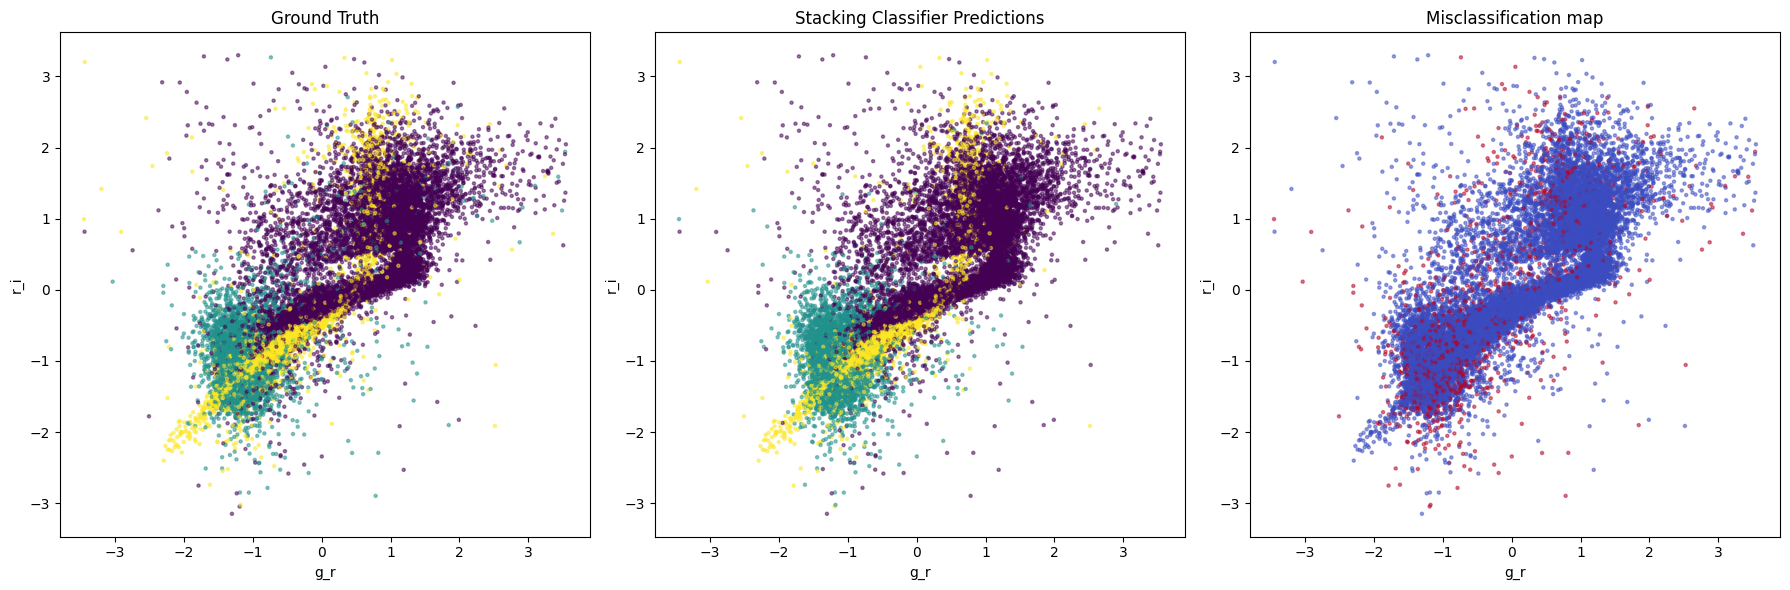

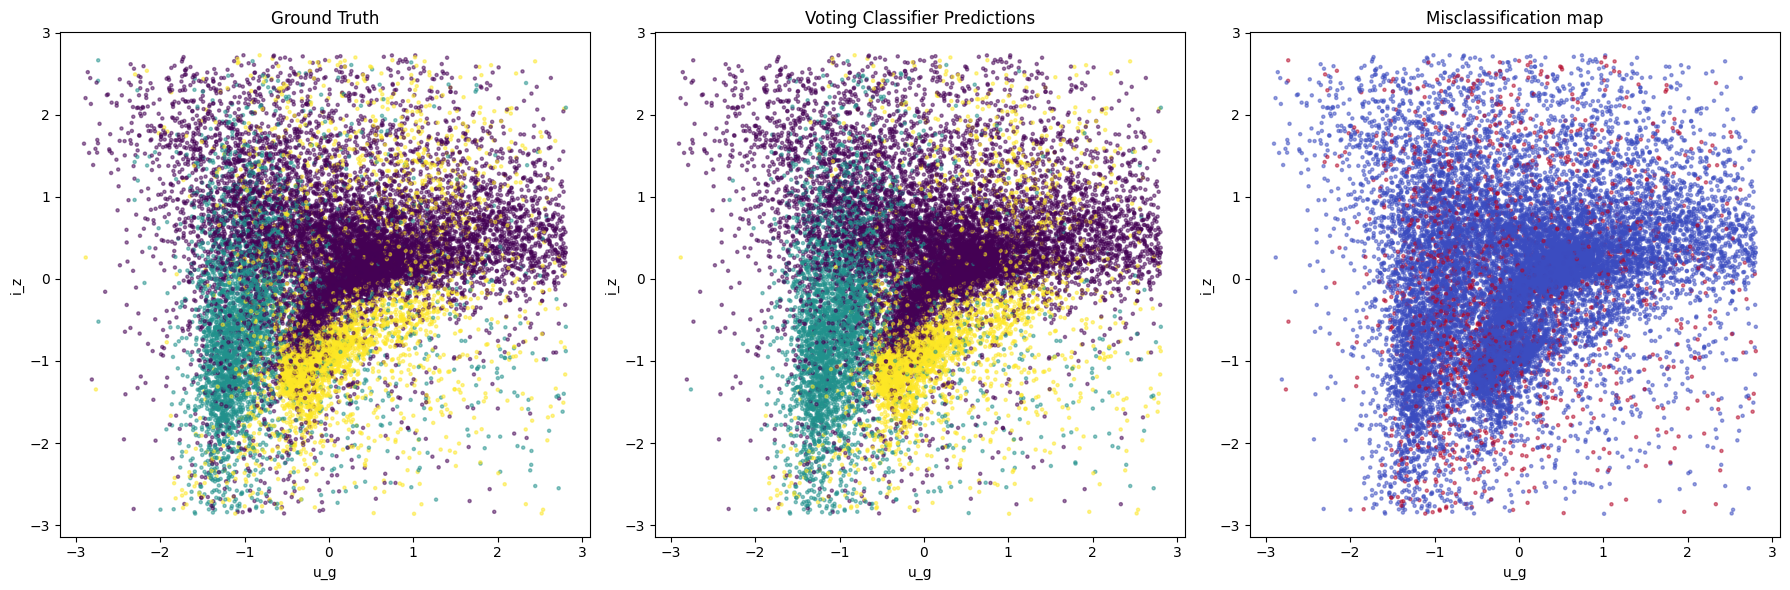

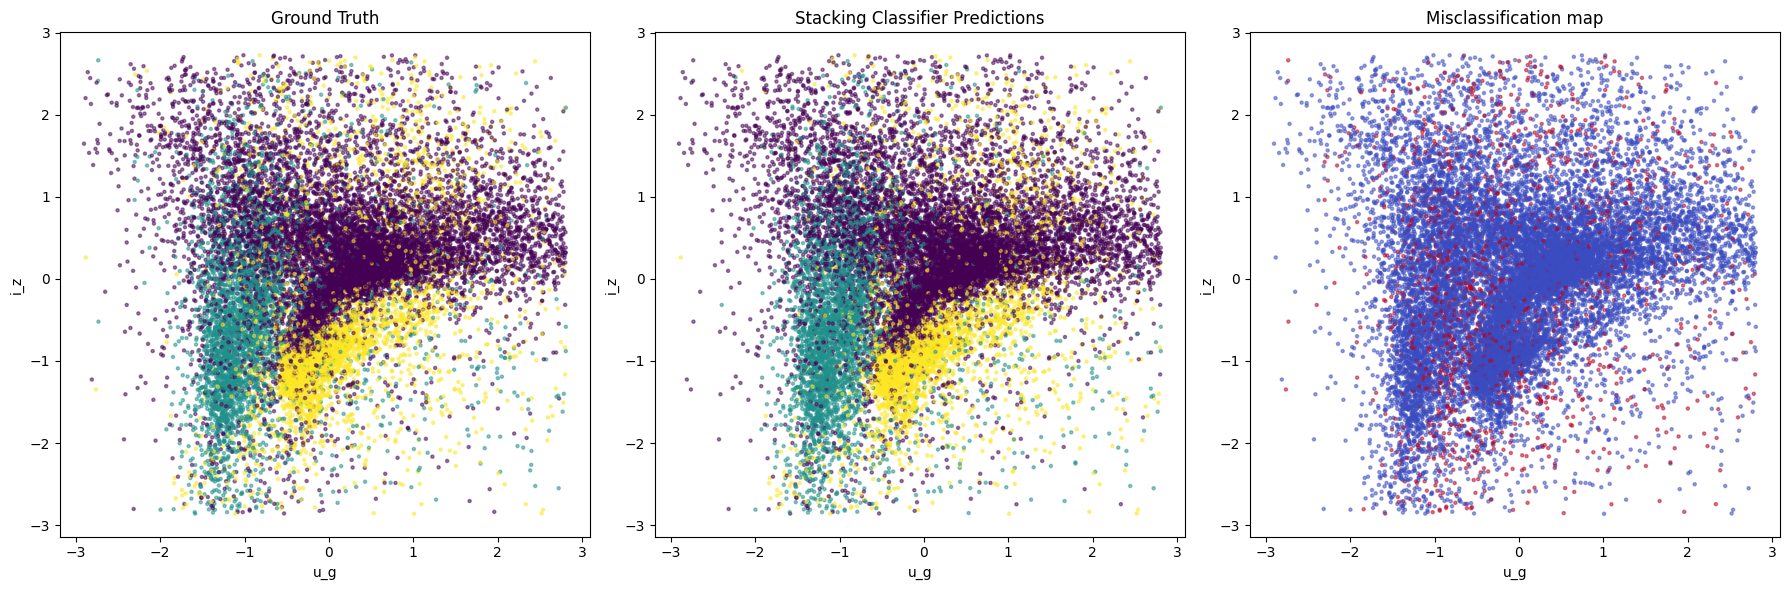

In [13]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_pred_voting = voting_clf.predict(X_test)
y_pred_stacking = stacking_clf.predict(X_test)

# g-r vs r-i
sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_voting,
    feature_x='g_r',
    feature_y='r_i',
    title_prefix='Voting Classifier'
)

sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_stacking,
    feature_x='g_r',
    feature_y='r_i',
    title_prefix='Stacking Classifier'
)

# u-g vs i-z
sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_voting,
    feature_x='u_g',
    feature_y='i_z',
    title_prefix='Voting Classifier'
)

sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_stacking,
    feature_x='u_g',
    feature_y='i_z',
    title_prefix='Stacking Classifier'
)

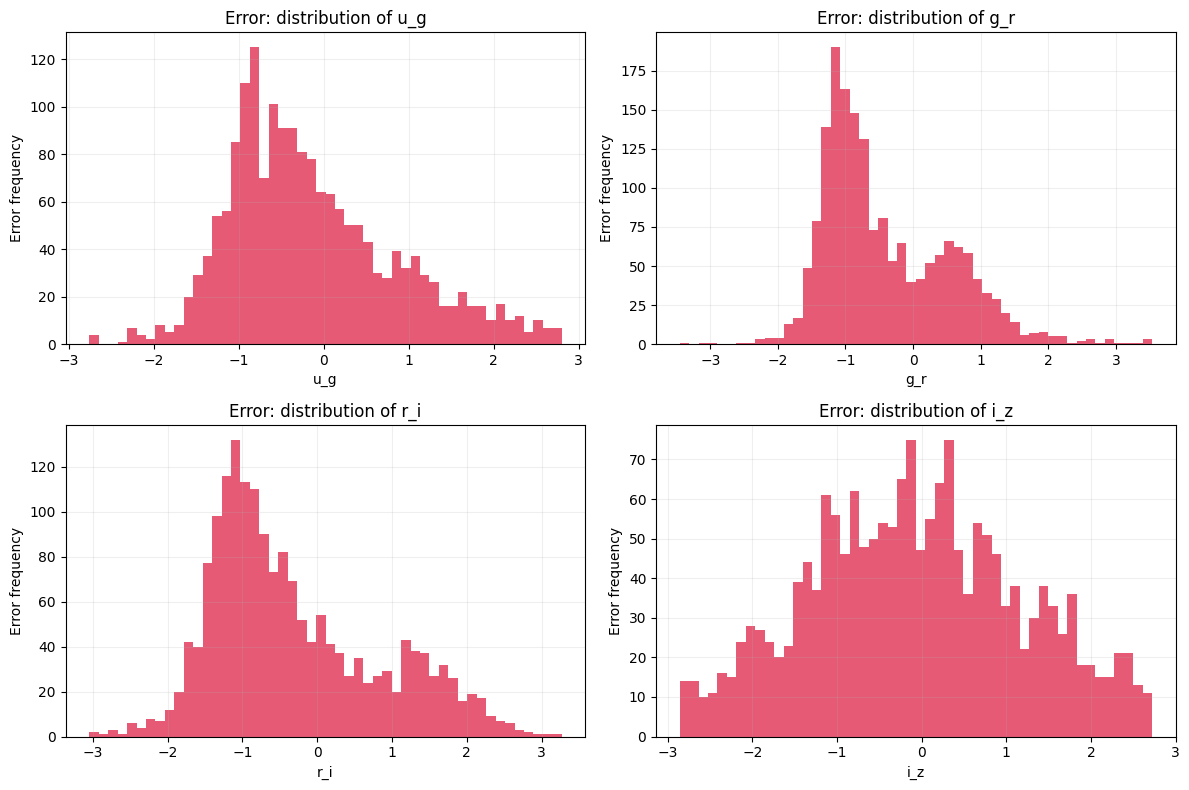

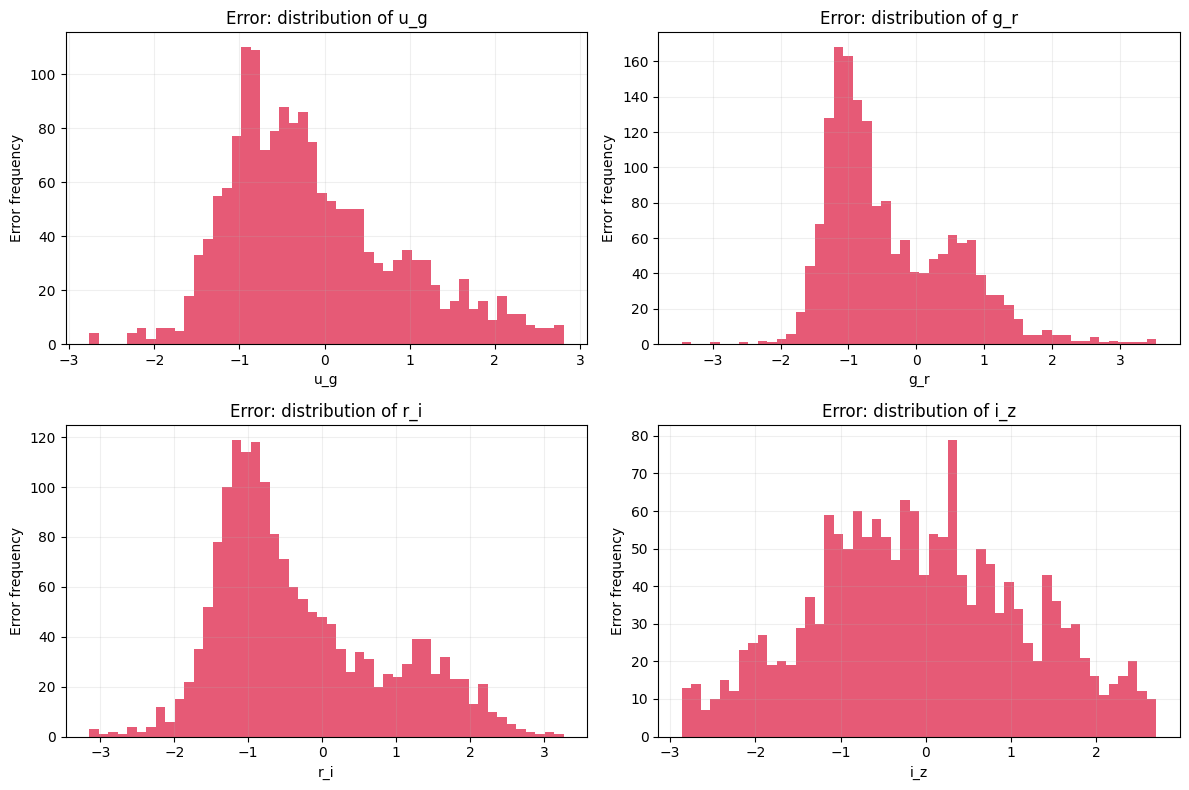

In [15]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_pred_stacking,
    features=["u_g", "g_r", "r_i", "i_z"]
)

sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_pred_voting,
    features=["u_g", "g_r", "r_i", "i_z"]
)